# Primer análisis: 
Voy a coger una barrera 'transparente', es decir, que el material de la barrera y el del medio sea el mismo, por lo que las masas efectivas son las mismas.
También voy a experimentar cambiando la masa efectiva de la barrera

Suponiendo que la energía de los KIENES es como máximo 0.1 eV, he ido cambiando la longitud de la barrera y me he quedado con el valor del coeficiente de transmisión para esa energía. 

Queremos buscar una barrera que permita que pasen, como máximo. 0.01% de los KIENES incidentes, es decir, T<$10^{-4}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Energia = 0.1
Barreramax = 0.4
hbarrac = 197.3269    # eV*nm
m0c2 = 511000   # eV


# =========================
# LEER LOS DOS ARCHIVOS
# =========================

matriz1 = np.loadtxt("T-L,E=0.1,m=0.067.txt", skiprows=1)
matriz2 = np.loadtxt("T-L,E=0.1,m=0.09.txt", skiprows=1)
matriz3 = np.loadtxt("T-L,E=0.1,m=0.15.txt", skiprows=1)
matriz4 = np.loadtxt("T-L,E=0.1,m=0.22.txt", skiprows=1)

L1 = matriz1[:, 0]
T1 = matriz1[:, 1]

L2 = matriz2[:, 0]
T2 = matriz2[:, 1]

L3 = matriz3[:, 0]
T3 = matriz3[:, 1]

T4 = matriz4[:, 1]
L4 = matriz4[:, 0]


def ajuste_exp_doble(L, A, b, C, D, f):
    return A*np.exp(b*L) + C*np.exp(-b*L) + D*np.exp(f*L)

# =========================
# AJUSTES EXPONENCIALES
# T(L) = A * exp(-B*L)
# ln(T) = ln(A) - B*L
# =========================

coef1 = np.polyfit(L1, np.log(T1), 1)
pendiente1 = coef1[0]
ordenada1 = coef1[1]

B1 = -pendiente1
A1 = np.exp(ordenada1)

coef2 = np.polyfit(L2, np.log(T2), 1)
pendiente2 = coef2[0]
ordenada2 = coef2[1]

B2 = -pendiente2
A2 = np.exp(ordenada2)

coef3 = np.polyfit(L3, np.log(T3), 1)
pendiente3 = coef3[0]
ordenada3 = coef3[1]

B3 = -pendiente3
A3 = np.exp(ordenada3)

coef4 = np.polyfit(L4, np.log(T4), 1)
pendiente4 = coef4[0]
ordenada4 = coef4[1]

B4 = -pendiente4
A4 = np.exp(ordenada4)



A = [A1, A2, A3, A4]
B = [B1, B2, B3, B4]
m = [0.067, 0.09, 0.15, 0.22]

print("AJUSTE PARA m = 0.067")
print("A1 =", A1)
print("B1 =", B1)
print(f"T1(L) = {A1:.6e} * exp(-{B1:.6f} * L)")
print(B1/np.sqrt(0.067))
print()

print("AJUSTE PARA m = 0.09")
print("A2 =", A2)
print("B2 =", B2)
print(f"T2(L) = {A2:.6e} * exp(-{B2:.6f} * L)")
print(B2/np.sqrt(0.09))
print()

print("AJUSTE PARA m = 0.15")
print("A3 =", A3)
print("B3 =", B3)
print(f"T3(L) = {A3:.6e} * exp(-{B3:.6f} * L)")
print(B3/np.sqrt(0.15))
print()

print("AJUSTE PARA m = 0.22")
print("A4 =", A4)
print("B4 =", B4)
print(f"T4(L) = {A4:.6e} * exp(-{B4:.6f} * L)")
print(B4/np.sqrt(0.22))

# =========================
# CURVAS DE AJUSTE
# =========================

L1_ajuste = np.linspace(min(L1), max(L1), 300)
T1_ajuste = A1 * np.exp(-B1 * L1_ajuste)

L2_ajuste = np.linspace(min(L2), max(L2), 300)
T2_ajuste = A2 * np.exp(-B2 * L2_ajuste)

L3_ajuste = np.linspace(min(L3), max(L3), 300)
T3_ajuste = A3 * np.exp(-B3 * L3_ajuste)

L4_ajuste = np.linspace(min(L4), max(L4), 300)
T4_ajuste = A4 * np.exp(-B4 * L4_ajuste)


AJUSTE PARA m = 0.067
A1 = 2.644308855481297
B1 = 1.4311348175477145
T1(L) = 2.644309e+00 * exp(-1.431135 * L)
5.528956159069755

AJUSTE PARA m = 0.09
A2 = 2.9674076125472832
B2 = 1.656464293525945
T2(L) = 2.967408e+00 * exp(-1.656464 * L)
5.521547645086484

AJUSTE PARA m = 0.15
A3 = 3.475649642460001
B3 = 2.1469176141088107
T3(L) = 3.475650e+00 * exp(-2.146918 * L)
5.54331744341519

AJUSTE PARA m = 0.22
A4 = 3.6470769179803577
B4 = 2.6082079848504534
T4(L) = 3.647077e+00 * exp(-2.608208 * L)
5.560718107745398


In [20]:
# Calculamos la Transmisión

def transmision(L, m):
    cte1 = (Barreramax**2)/(4*Energia*(Barreramax - Energia))
    cte2 = np.sqrt(2*m*m0c2*(Barreramax - Energia))*L/hbarrac
    return 1/(1 + cte1*np.sinh(cte2)**2)

L = np.linspace(0.5, 8.5, 20)

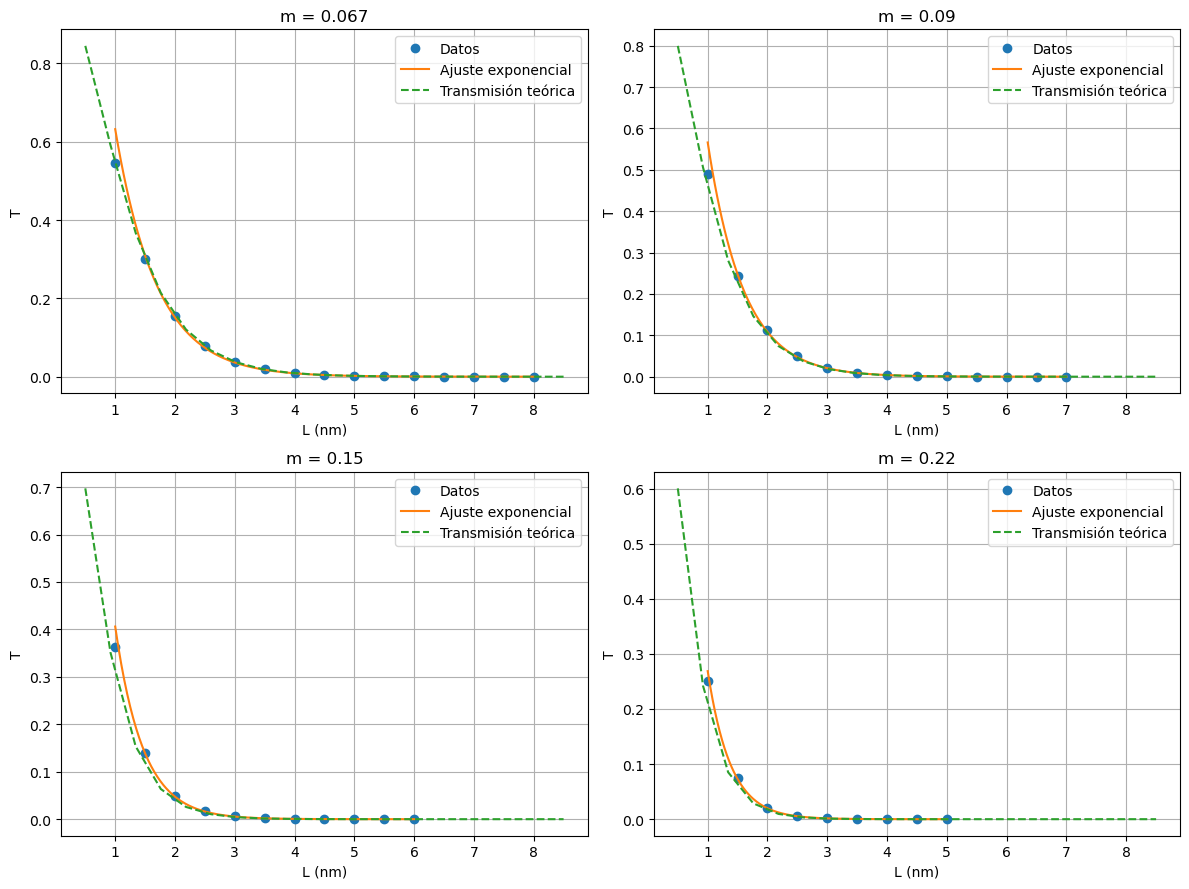

In [22]:
# =========================
# GRAFICAS LADO A LADO
# =========================

plt.figure(figsize=(12,9))

plt.subplot(2, 2, 1)
plt.plot(L1, T1, 'o', label="Datos")
plt.plot(L1_ajuste, T1_ajuste, '-', label="Ajuste exponencial")
plt.plot(L, transmision(L, 0.067), '--', label="Transmisión teórica")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.067")
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(L2, T2, 'o', label="Datos")
plt.plot(L2_ajuste, T2_ajuste, '-', label="Ajuste exponencial")
plt.plot(L, transmision(L, 0.09), '--', label="Transmisión teórica")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.09")
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(L3, T3, 'o', label="Datos")
plt.plot(L3_ajuste, T3_ajuste, '-', label="Ajuste exponencial")
plt.plot(L, transmision(L, 0.15), '--', label="Transmisión teórica")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.15")
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(L4, T4, 'o', label="Datos")
plt.plot(L4_ajuste, T4_ajuste, '-', label="Ajuste exponencial")
plt.plot(L, transmision(L, 0.22), '--', label="Transmisión teórica")
plt.xlabel("L (nm)")
plt.ylabel("T")
plt.title("m = 0.22")
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()

Conclusiones a bote pronto, La A no debería cambiar con la masa, y vamos a ver como cambia

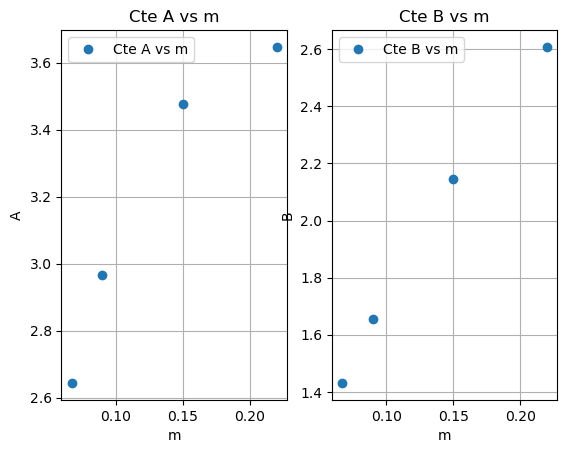

In [18]:
plt.subplot(1, 2, 1)
plt.plot(m, A, 'o', label="Cte A vs m")
plt.xlabel("m")
plt.ylabel("A")
plt.title("Cte A vs m")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(m, B, 'o', label="Cte B vs m")
plt.xlabel("m")
plt.ylabel("B")
plt.title("Cte B vs m")
plt.grid(True)
plt.legend()


Ajuste: A = 4.789681*sqrt(m) + 1.489041
R^2 = 0.946667
Ajuste: B = 5.605828*sqrt(m) + -0.022638
R^2 = 0.999977


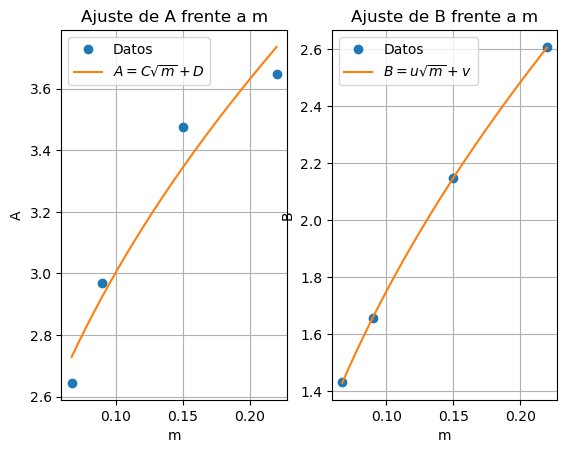

In [19]:
m = np.array(m)
A = np.array(A)

# Ajuste A = C*sqrt(m) + D
x = np.sqrt(m)

coef = np.polyfit(x, A, 1)
C = coef[0]
D = coef[1]

A_ajuste = C*np.sqrt(m) + D

# R^2
ss_res = np.sum((A - A_ajuste)**2)
ss_tot = np.sum((A - np.mean(A))**2)
R2 = 1 - ss_res/ss_tot

print(f"Ajuste: A = {C:.6f}*sqrt(m) + {D:.6f}")
print(f"R^2 = {R2:.6f}")

# Curva suave
m_suave = np.linspace(min(m), max(m), 300)
A_suave = C*np.sqrt(m_suave) + D

plt.subplot(1, 2, 1)
plt.plot(m, A, 'o', label="Datos")
plt.plot(m_suave, A_suave, '-', label=r"$A=C\sqrt{m}+D$")
plt.xlabel("m")
plt.ylabel("A")
plt.title("Ajuste de A frente a m")
plt.grid(True)
plt.legend()





m = np.array(m)
B_datos = np.array(B)

# Ajuste: B_datos = u*sqrt(m) + v
variable_raiz = np.sqrt(m)

coeficientes = np.polyfit(variable_raiz, B_datos, 1)
u = coeficientes[0]
v = coeficientes[1]

B_calculada = u*variable_raiz + v

# R^2
suma_residuos = np.sum((B_datos - B_calculada)**2)
suma_total = np.sum((B_datos - np.mean(B_datos))**2)
R2_raiz = 1 - suma_residuos/suma_total

print(f"Ajuste: B = {u:.6f}*sqrt(m) + {v:.6f}")
print(f"R^2 = {R2_raiz:.6f}")

# Curva suave
m_suaveb = np.linspace(min(m), max(m), 300)
B_suave = u*np.sqrt(m_suave) + v

# Gráfica
plt.subplot(1, 2, 2)
plt.plot(m, B_datos, 'o', label="Datos")
plt.plot(m_suaveb, B_suave, '-', label=r"$B=u\sqrt{m}+v$")
plt.xlabel("m")
plt.ylabel("B")
plt.title("Ajuste de B frente a m")
plt.grid(True)
plt.legend()
plt.show()



No termino de encontrar un ajuste para A